This is a simple notebook to show the effect of Ridge and Lasso regularization.  
It accompanies Chapter 5 of the book (3 of 5).  
Copyright: Viviana Acquaviva (2023)  
Modified by Aaron Romanowsky.
License: [BSD-3-clause](https://opensource.org/license/bsd-3-clause/)

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn import linear_model
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_validate, cross_val_predict, KFold

font = {'size'   : 16}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=14) 
matplotlib.rc('ytick', labelsize=14) 
matplotlib.rcParams.update({'figure.autolayout': False})
matplotlib.rcParams['figure.dpi'] = 300

Start off with 3-feature sample $y(x_1,x_2,x_3)$  

In [2]:
np.random.seed(16) #set seed for reproducibility purposes
x1 = np.arange(100) 
x2 = np.linspace(0,1,100)
x3 = np.logspace(2,3,num=100) 
ypb = 3*x1 + 0.5*x2 + 15*x3 + 3 + 5*(np.random.poisson(3*x1 + 0.5*x2 + 15*x3,100)-(3*x1 + 0.5*x2 + 15*x3)) 
                                                    #generate some data with scatter following Poisson distribution 
                                                    #with exp value = y from linear model, centered around 0

In [3]:
xb = np.vstack((x1,x2,x3)).T
#xb.shape
print(xb[:10]) # first 10 rows

[[0.00000000e+00 0.00000000e+00 1.00000000e+02]
 [1.00000000e+00 1.01010101e-02 1.02353102e+02]
 [2.00000000e+00 2.02020202e-02 1.04761575e+02]
 [3.00000000e+00 3.03030303e-02 1.07226722e+02]
 [4.00000000e+00 4.04040404e-02 1.09749877e+02]
 [5.00000000e+00 5.05050505e-02 1.12332403e+02]
 [6.00000000e+00 6.06060606e-02 1.14975700e+02]
 [7.00000000e+00 7.07070707e-02 1.17681195e+02]
 [8.00000000e+00 8.08080808e-02 1.20450354e+02]
 [9.00000000e+00 9.09090909e-02 1.23284674e+02]]


### Add correlated features (polynomial transformation)

Transform to 9 features $y(x_1,x_2,x_3,x_1^2,x_1x_2,x_1x_3,x_2^2,x_2x_3,x_3^2)$

In [4]:
poly = PolynomialFeatures(2, include_bias=False)
new_xb = poly.fit_transform(xb)
#new_xb.shape
print(new_xb[:10]) # first 10 rows

[[0.00000000e+00 0.00000000e+00 1.00000000e+02 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  1.00000000e+04]
 [1.00000000e+00 1.01010101e-02 1.02353102e+02 1.00000000e+00
  1.01010101e-02 1.02353102e+02 1.02030405e-04 1.03386972e+00
  1.04761575e+04]
 [2.00000000e+00 2.02020202e-02 1.04761575e+02 4.00000000e+00
  4.04040404e-02 2.09523151e+02 4.08121620e-04 2.11639546e+00
  1.09749877e+04]
 [3.00000000e+00 3.03030303e-02 1.07226722e+02 9.00000000e+00
  9.09090909e-02 3.21680167e+02 9.18273646e-04 3.24929461e+00
  1.14975700e+04]
 [4.00000000e+00 4.04040404e-02 1.09749877e+02 1.60000000e+01
  1.61616162e-01 4.38999506e+02 1.63248648e-03 4.43433845e+00
  1.20450354e+04]
 [5.00000000e+00 5.05050505e-02 1.12332403e+02 2.50000000e+01
  2.52525253e-01 5.61662016e+02 2.55076013e-03 5.67335370e+00
  1.26185688e+04]
 [6.00000000e+00 6.06060606e-02 1.14975700e+02 3.60000000e+01
  3.63636364e-01 6.89854197e+02 3.67309458e-03 6.96822421e+00
  1.32194115e+04]
 [7.00

(1000.0, 20000.0)

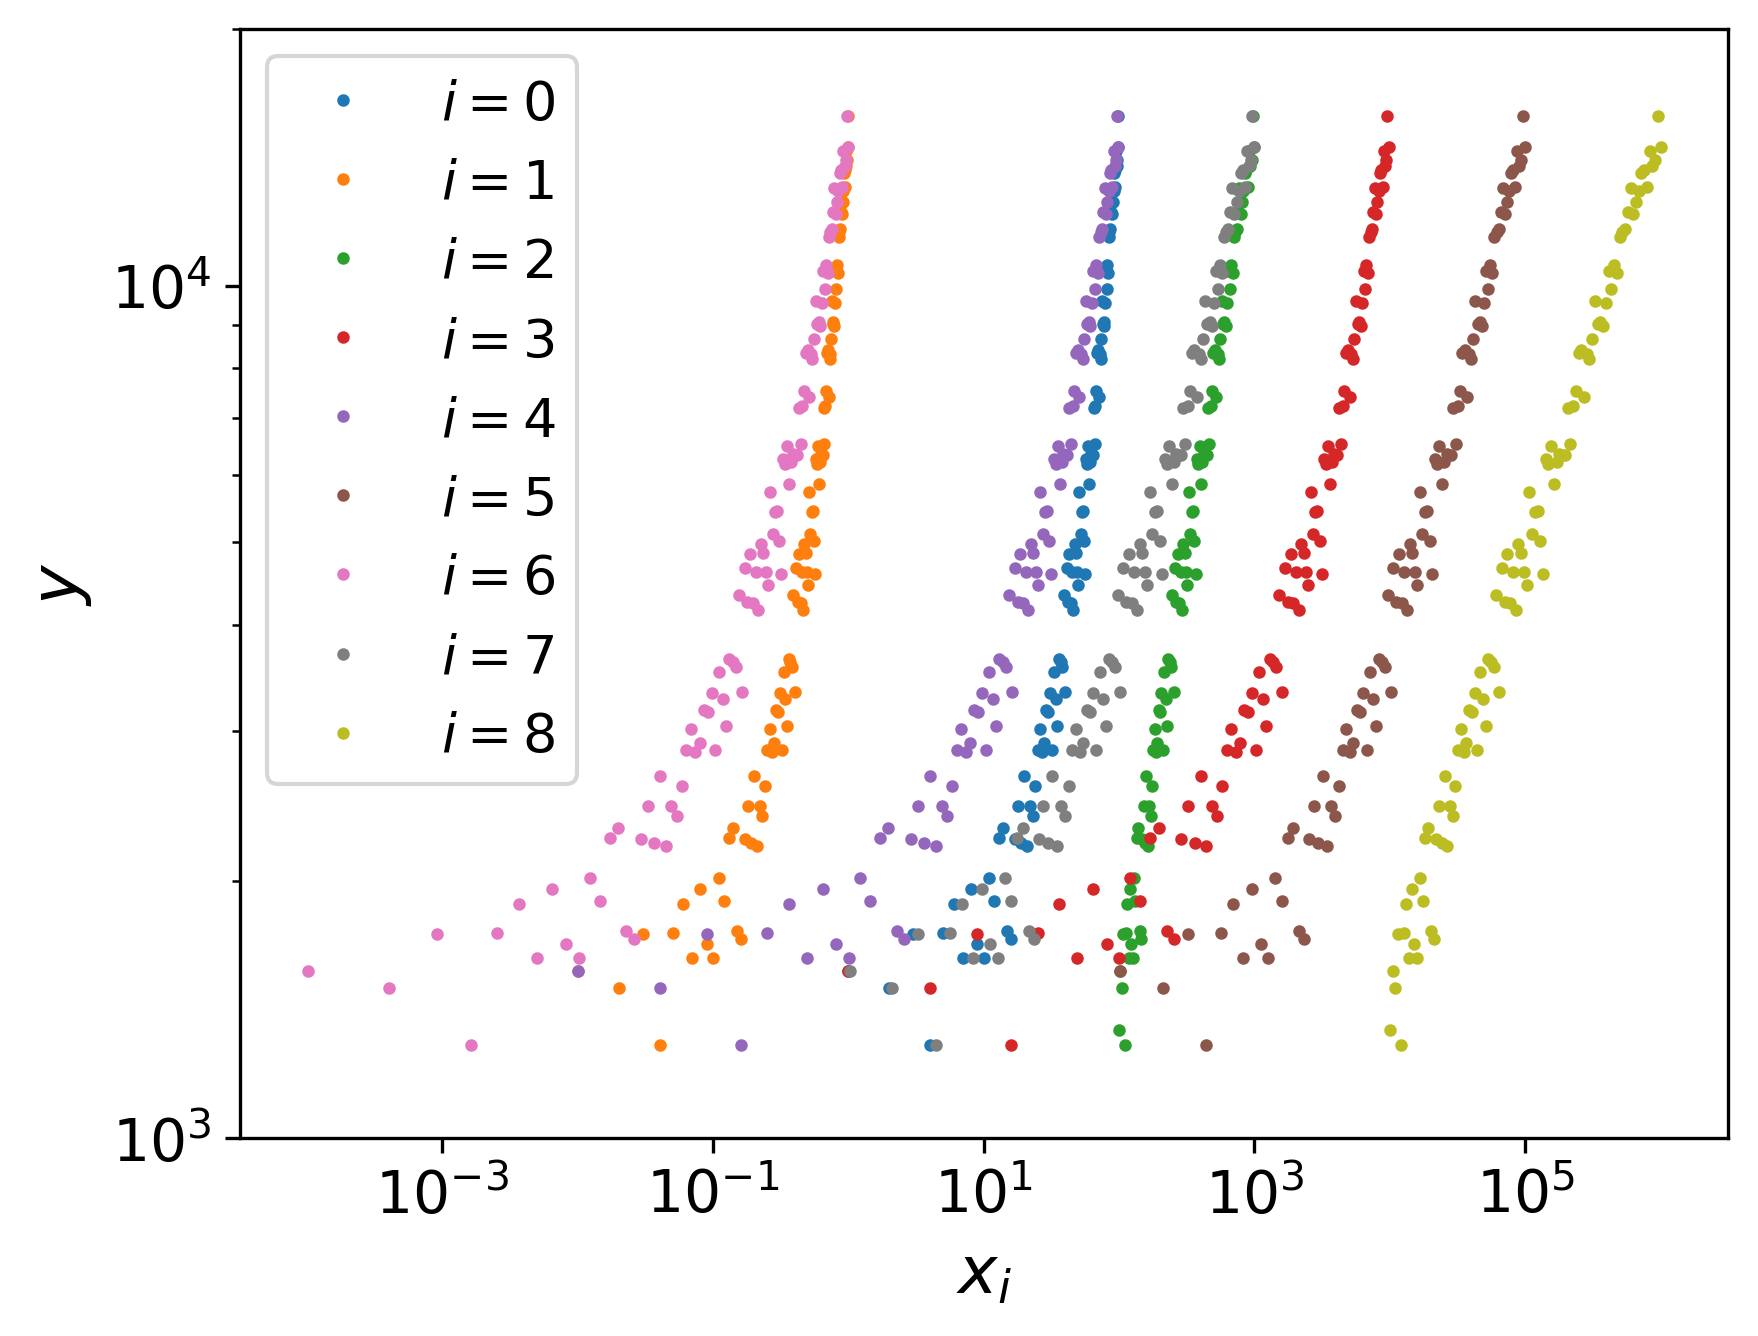

In [5]:
fig1 = plt.figure()
for i in range(9) :
    plt.plot(new_xb[:,i], ypb,'o', ms=2, label='$i=$'+str(i))
plt.legend(loc='best',fontsize=13)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$x_i$')
plt.ylabel('$y$')
plt.ylim(1e3,2e4)

### Let's start with Ridge regression, and tune $\alpha$ using cross-validation.
(note what happens if repeating a few times without fixing the random seed).

In [7]:
MSE = []

for alpha in np.logspace(-6,6,13):
    model_reg = make_pipeline(StandardScaler(), Ridge(alpha = alpha, max_iter=10000)) #normalization helps convergence
    scores = cross_validate(model_reg, new_xb, ypb, cv = KFold(n_splits=5, shuffle=True, random_state = 1), scoring = 'neg_mean_squared_error')
    print('alpha=', alpha, 'MSE=', np.round(-np.mean(scores['test_score']))) #Note however that this only outputs the MSE
    MSE.append(-np.mean(scores['test_score']))
print('Best alpha:', np.logspace(-6,6,13)[np.argmin(MSE)])

alpha= 1e-06 MSE= 165716.0
alpha= 1e-05 MSE= 169659.0
alpha= 0.0001 MSE= 172897.0
alpha= 0.001 MSE= 172925.0
alpha= 0.01 MSE= 172534.0
alpha= 0.1 MSE= 173950.0
alpha= 1.0 MSE= 167349.0
alpha= 10.0 MSE= 162459.0
alpha= 100.0 MSE= 399386.0
alpha= 1000.0 MSE= 5641871.0
alpha= 10000.0 MSE= 14052891.0
alpha= 100000.0 MSE= 15852931.0
alpha= 1000000.0 MSE= 16051906.0
Best alpha: 10.0


### There is also a built-in instrument for this!

In [13]:
from sklearn.linear_model import RidgeCV

In [14]:
regm = make_pipeline(StandardScaler(with_mean=False),
                     RidgeCV(alphas=np.logspace(-6,6,13), \
            cv = KFold(n_splits=5, shuffle=True, random_state=1),\
             scoring = 'neg_mean_squared_error'))

regm.fit(new_xb,ypb) 

print('The best alpha is', regm[1].alpha_)

The best alpha is 10.0


(1000.0, 20000.0)

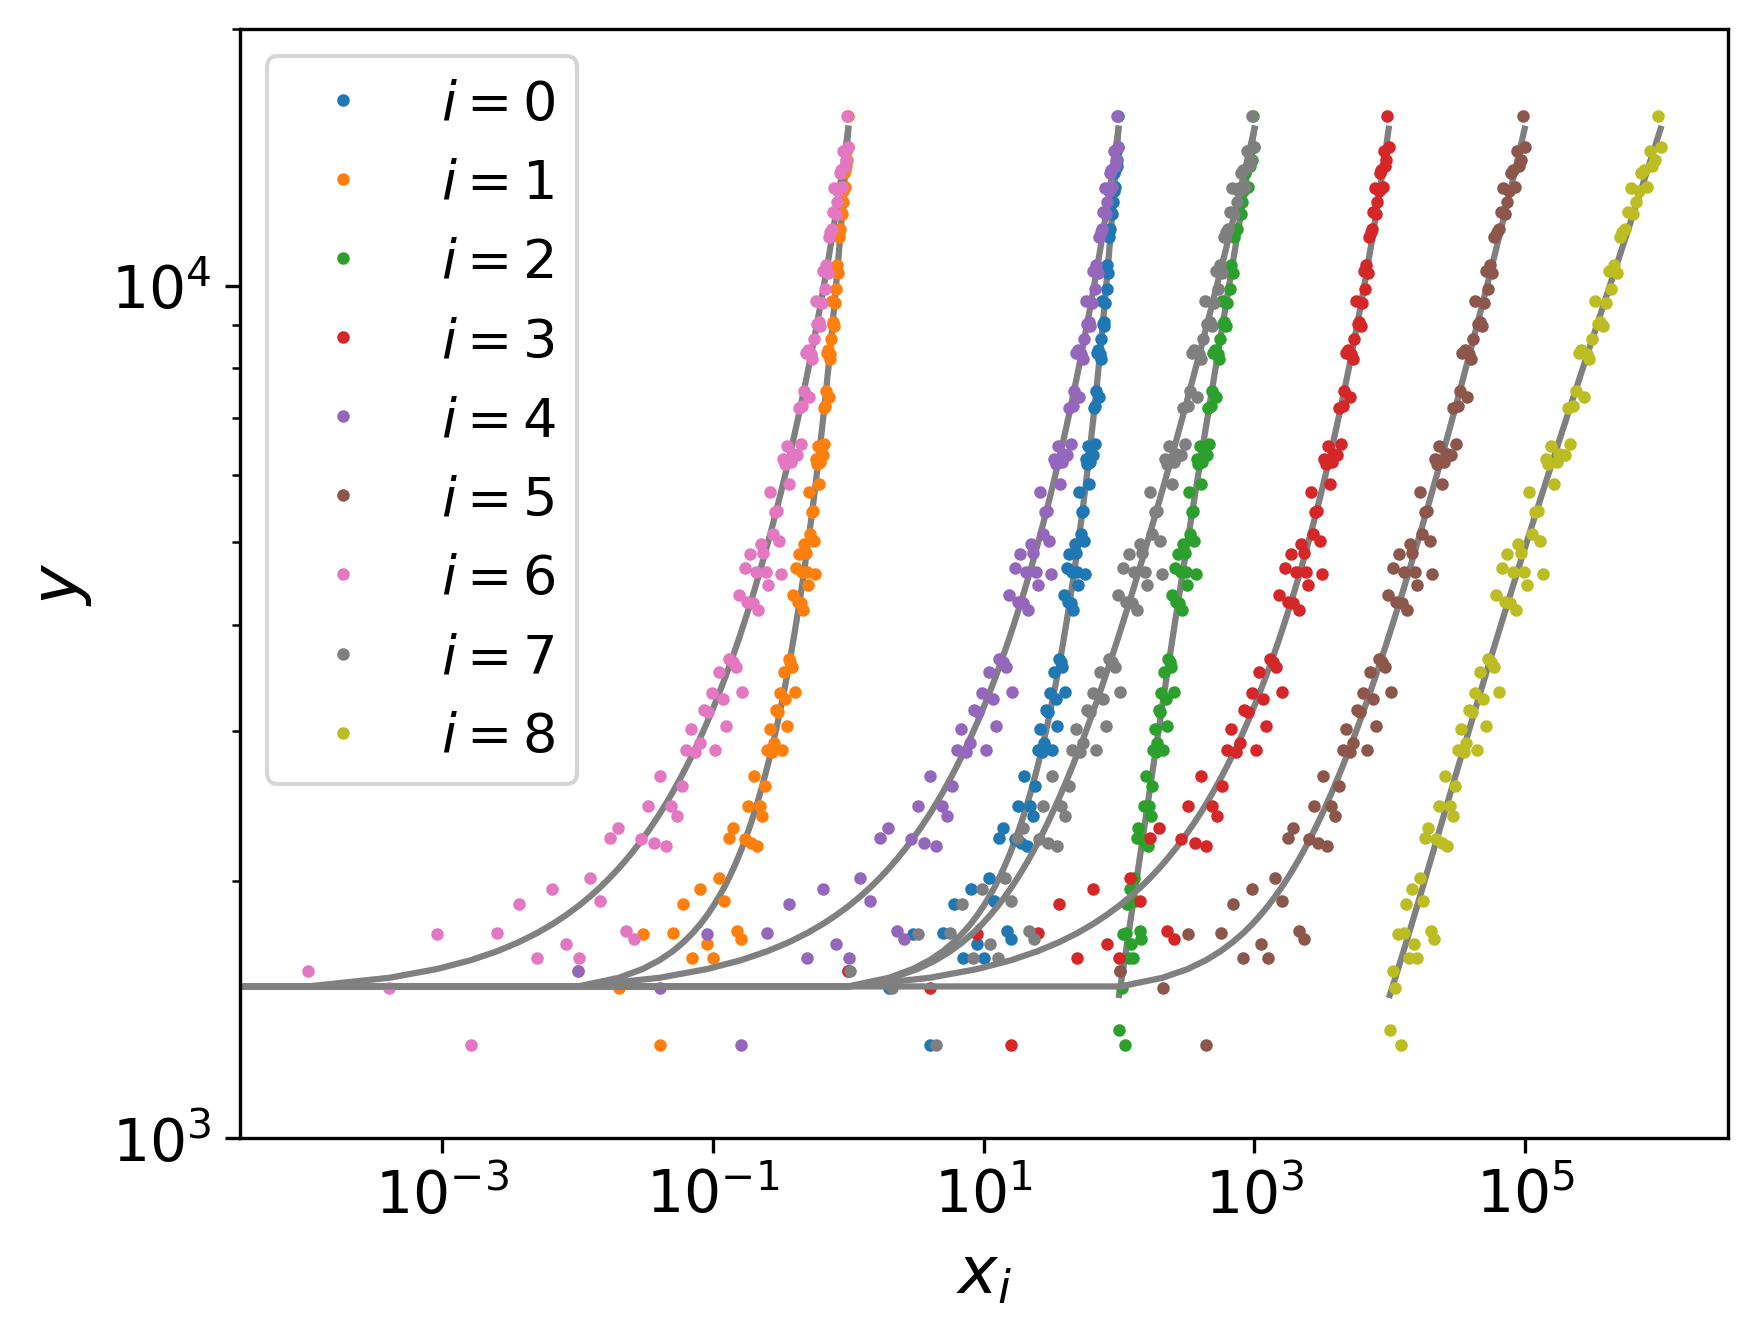

In [15]:
ypred = regm.predict(new_xb)
fig2 = plt.figure()
for i in range(9) :
    plt.plot(new_xb[:,i], ypred, '-', c='gray')
    plt.plot(new_xb[:,i], ypb,'o', ms=2, label='$i=$'+str(i))
plt.legend(loc='best',fontsize=13)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$x_i$')
plt.ylabel('$y$')
plt.ylim(1e3,2e4)

### We can compare the coefficients of the linear model for different amounts of regularization.

#### Let's pick $\alpha = 1000$.

In [16]:
#Note: the notation changed in sklearn 1.2 and higher; 
#To reproduce book results, we need to use alpha = alpha * n_samples

newmodel = make_pipeline(StandardScaler(with_mean=False), Ridge(alpha=1000*new_xb.shape[0]))
newmodel.fit(new_xb,ypb)
coef_alpha_1000 = np.hstack([newmodel[1].coef_/newmodel[0].scale_, newmodel[1].intercept_])                 
print(coef_alpha_1000)

[1.29764875e-01 1.28467226e+01 1.54128052e-02 1.31732946e-03
 1.30415617e-01 1.42251352e-04 1.29111460e+01 1.40828839e-02
 1.48143307e-05 5.99685176e+03]


#### Now let's see for $\alpha = 1.0$.

Will the coefficients be larger or smaller?

In [17]:
#Note: the notation changed in sklearn 1.2 and higher; 
#To reproduce book results, we need to use alpha = alpha * n_samples

newmodel = make_pipeline(StandardScaler(with_mean=False), Ridge(alpha=1*new_xb.shape[0]))
newmodel.fit(new_xb,ypb)
coef_alpha_1 = np.hstack([newmodel[1].coef_/newmodel[0].scale_, newmodel[1].intercept_])           
print(coef_alpha_1)

[1.29503196e+01 1.28208164e+03 1.59973226e+00 1.36205885e-01
 1.34843826e+01 1.49543095e-02 1.33495388e+03 1.48047664e+00
 1.57290083e-03 1.65472805e+03]


#### Finally, below we use a trick to get coefficients for "zero" $\alpha$ (no regularization); we could have also used LinearRegressor.

In [18]:
newmodel = make_pipeline(StandardScaler(with_mean=False), Ridge(alpha=1e-11*new_xb.shape[0]))
newmodel.fit(new_xb,ypb)
coef_alpha_noreg = np.hstack([newmodel[1].coef_/newmodel[0].scale_, newmodel[1].intercept_])   
print(coef_alpha_noreg)

[ 9.89118699e+02  9.79175281e+04 -1.20196325e+03  5.22659668e+00
  5.17436631e+02  4.44319313e+00  5.12399684e+04  4.39872951e+02
 -1.35516895e-01  1.23072660e+05]


Comparison with the same procedure for the linear model (no regularization) shows consistency.

In [19]:
lmodel = make_pipeline(StandardScaler(with_mean=False),linear_model.LinearRegression())
lmodel.fit(new_xb,ypb)
print(lmodel[1].coef_/lmodel[0].scale_, lmodel[1].intercept_)

[ 9.89288883e+02  9.79395994e+04 -1.20220568e+03  5.22820851e+00
  5.17592643e+02  4.44403390e+00  5.12416716e+04  4.39959356e+02
 -1.35540533e-01] 123097.1829107434


### We can compare the coefficients for the three cases.

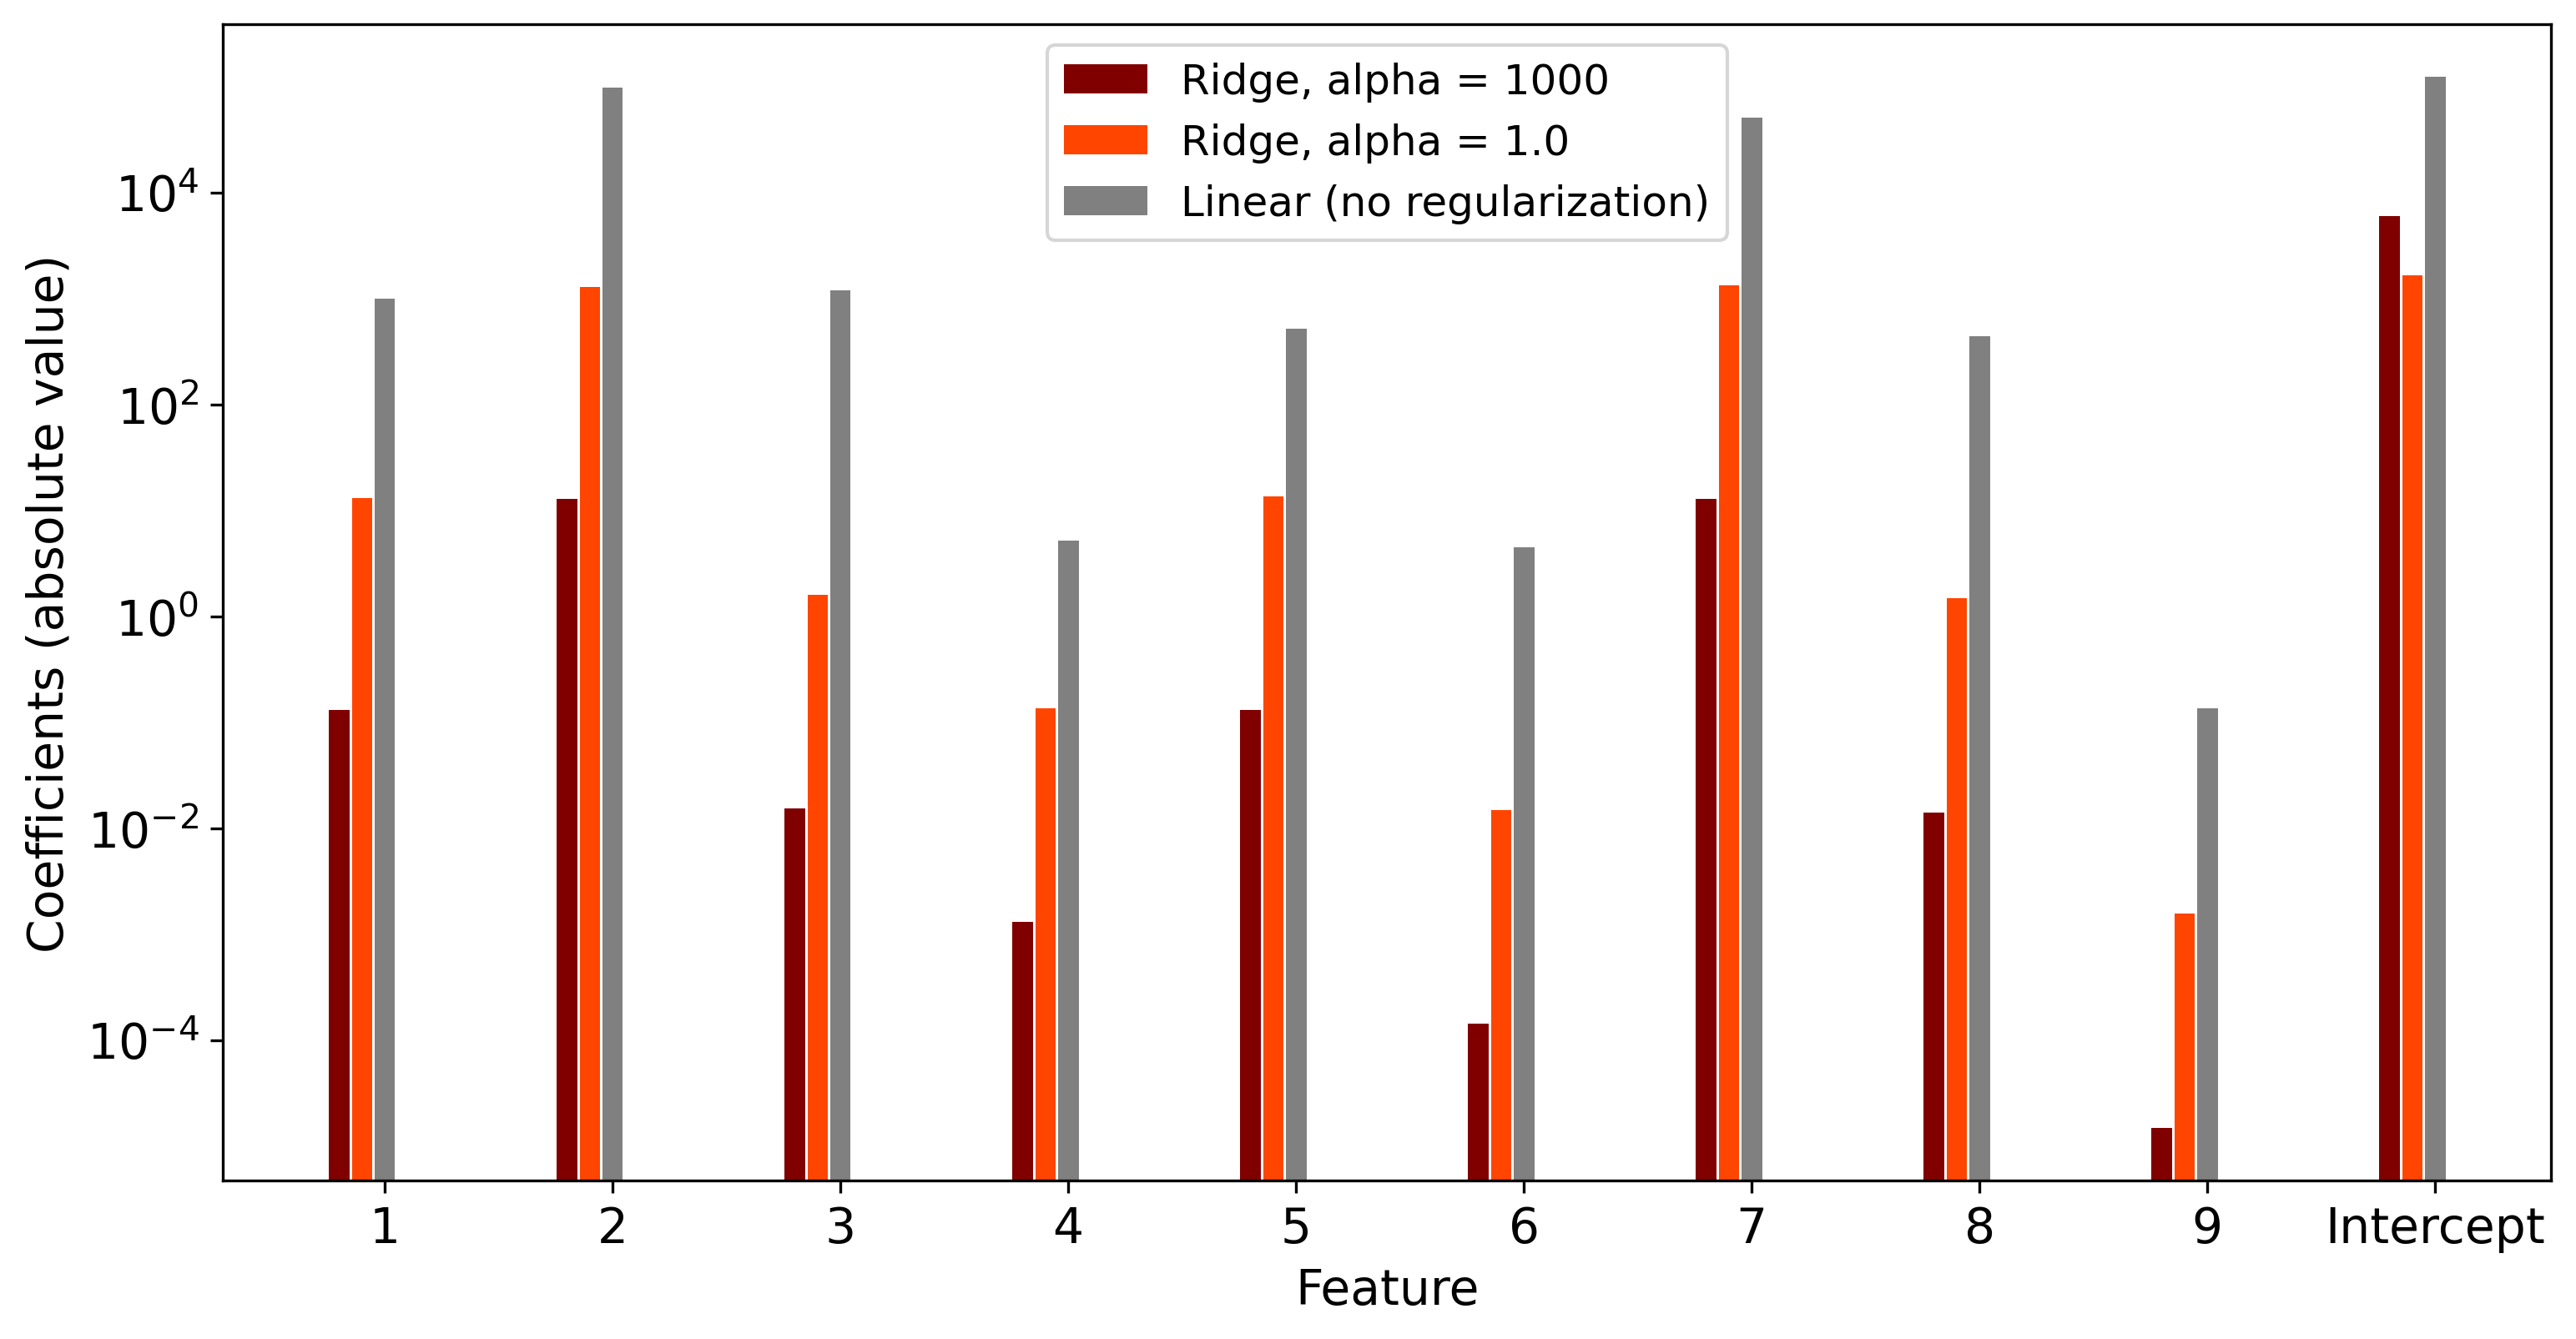

In [20]:
fig3 = plt.figure(figsize = (12,6))
plt.bar(np.arange(10)-0.2, np.abs(coef_alpha_1000), color = 'maroon',width=0.09, label = 'Ridge, alpha = 1000')
plt.bar(np.arange(10)-0.1, np.abs(coef_alpha_1), color = 'orangered',width=0.09, label = 'Ridge, alpha = 1.0')
plt.bar(range(10), np.abs(coef_alpha_noreg), color = 'grey',width=0.09, label = 'Linear (no regularization)')
plt.yscale('log')
plt.xticks(np.arange(10), ['1','2', '3','4','5','6','7','8','9', 'Intercept'])  # Set text labels.
plt.xlabel('Feature',fontsize=14)
plt.ylabel('Coefficients (absolute value)',fontsize=14)
plt.legend(fontsize=12, loc='upper center')

### Let us now take a look at LASSO.

In [21]:
from sklearn.linear_model import Lasso, LassoCV 

In [22]:
#Note: LassoCV re-orders alphas in DESCENDING ORDER! Scores will be messed up unless you use model.alphas_ object

model = make_pipeline(StandardScaler(with_mean = False), \
                      LassoCV(alphas = np.logspace(-1,4,6), 
                        cv = KFold(n_splits=5, shuffle=True, random_state=1), \
              max_iter = 10000000, tol = 1e-6))

model.fit(new_xb,ypb)
print('Alphas', model[1].alphas_)
print('Best alpha:', model[1].alpha_)

for i, alpha in enumerate(model[1].alphas_):
    print('Score for alpha', alpha, np.mean(model[1].mse_path_[i,:])) #for each alpha (row), mean of CV estimate of MSE

Alphas [1.e+04 1.e+03 1.e+02 1.e+01 1.e+00 1.e-01]
Best alpha: 100.0
Score for alpha 10000.0 16074247.370264316
Score for alpha 1000.0 1296703.831309507
Score for alpha 100.0 167356.81273155272
Score for alpha 10.0 168266.01745134155
Score for alpha 1.0 171883.8956254655
Score for alpha 0.1 175778.99191340682


#### <font color = 'red'> Note: early reproducibility issues were solved by setting tolerance to a small value (thanks to Joel Zinn!). </font>

Let's look at the coefficients for $\alpha = 1000$ and $\alpha = 1$.  
Lasso regularization tends to induce sparse coefficients, so we can check that that's true!

In [23]:
L1000 = make_pipeline(StandardScaler(with_mean=False), Lasso(alpha = np.sqrt(new_xb.shape[0])*1000, max_iter = 1000000, tol = 0.005))
L1000.fit(new_xb, ypb)
coef_L1000 =  np.hstack([L1000[1].coef_, L1000[1].intercept_])
print(coef_L1000)
ypred1000 = L1000.predict(new_xb)

[   0.           0.           0.           0.           0.
    0.           0.           0.           0.        6039.4703773]


In [24]:
L1 = make_pipeline(StandardScaler(with_mean=False), Lasso(alpha = np.sqrt(new_xb.shape[0])*1, max_iter = 1000000, tol = 0.005))
L1.fit(new_xb, ypb)
coef_L1 =  np.hstack([L1[1].coef_/L1[0].scale_, L1[1].intercept_])
print(coef_L1)
ypred1 = L1.predict(new_xb)

[2.83619997e+01 1.11863465e-11 7.99924234e+00 1.89893109e-02
 8.00308822e-16 2.12275841e-02 1.81554156e+00 0.00000000e+00
 1.93916019e-03 4.49575486e+02]


### Finally, we can plot all the coefficients together.

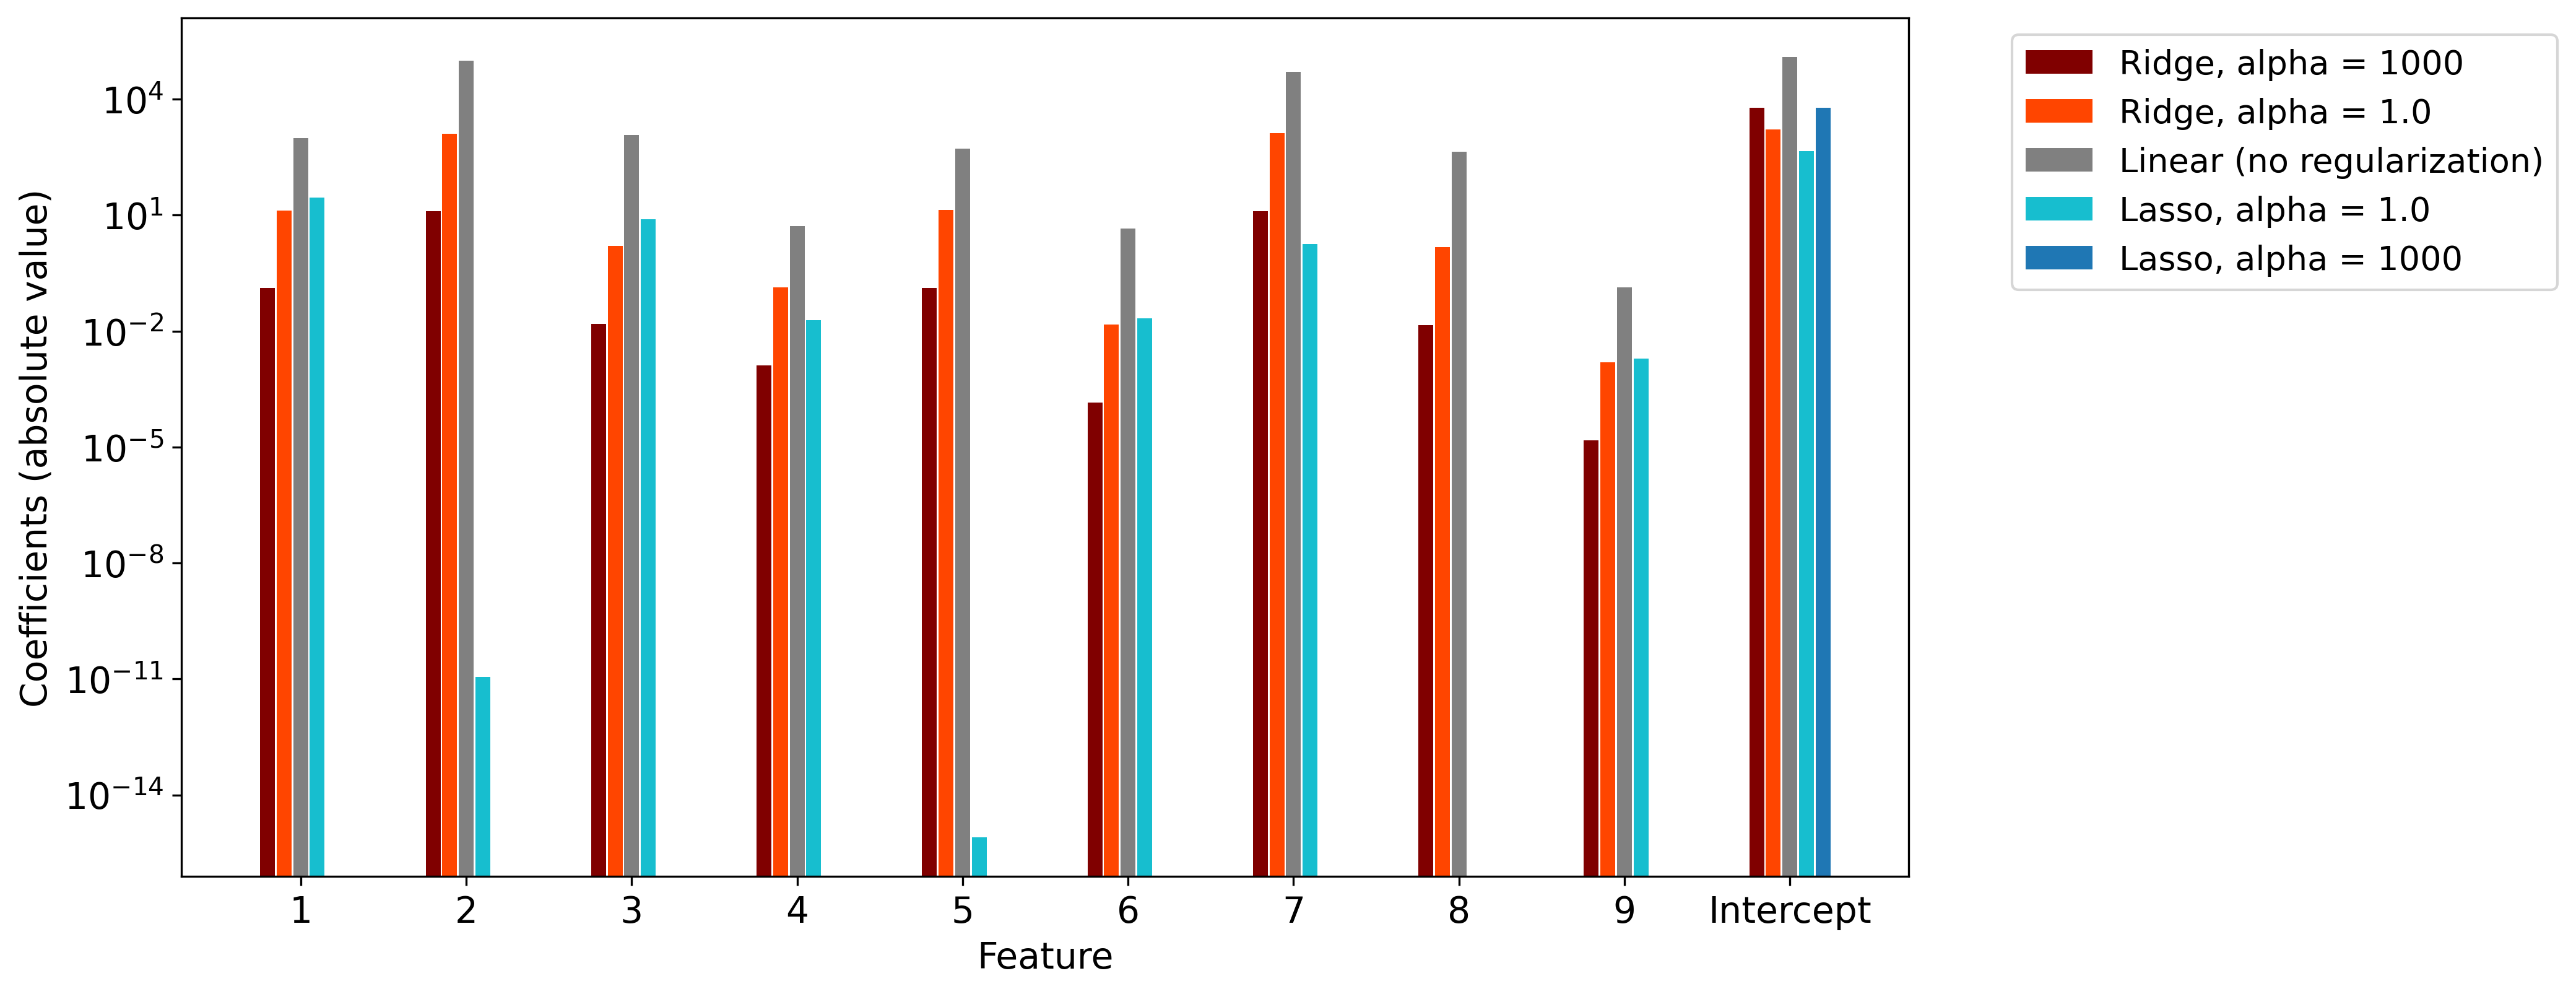

In [25]:
fig4 = plt.figure(figsize = (12,6))
plt.bar(np.arange(10)-0.2, np.abs(coef_alpha_1000), color = 'maroon',width=0.09, label = 'Ridge, alpha = 1000')
plt.bar(np.arange(10)-0.1, np.abs(coef_alpha_1), color = 'orangered',width=0.09, label = 'Ridge, alpha = 1.0')
plt.bar(range(10), np.abs(coef_alpha_noreg), color = 'grey',width=0.09, label = 'Linear (no regularization)')
plt.bar(np.arange(10)+0.1, np.abs(coef_L1), color = 'tab:cyan',width=0.09, label = 'Lasso, alpha = 1.0')
plt.bar(np.arange(10)+0.2, np.abs(coef_L1000), color = 'tab:blue', width=0.09, label = 'Lasso, alpha = 1000')
plt.yscale('log')
plt.xticks(np.arange(10), ['1','2', '3','4','5','6','7','8','9', 'Intercept'])  # Set text labels.
plt.xlabel('Feature',fontsize=14)
plt.ylabel('Coefficients (absolute value)',fontsize=14)
plt.legend(fontsize=13, bbox_to_anchor=(1.05, 1))

(1000.0, 20000.0)

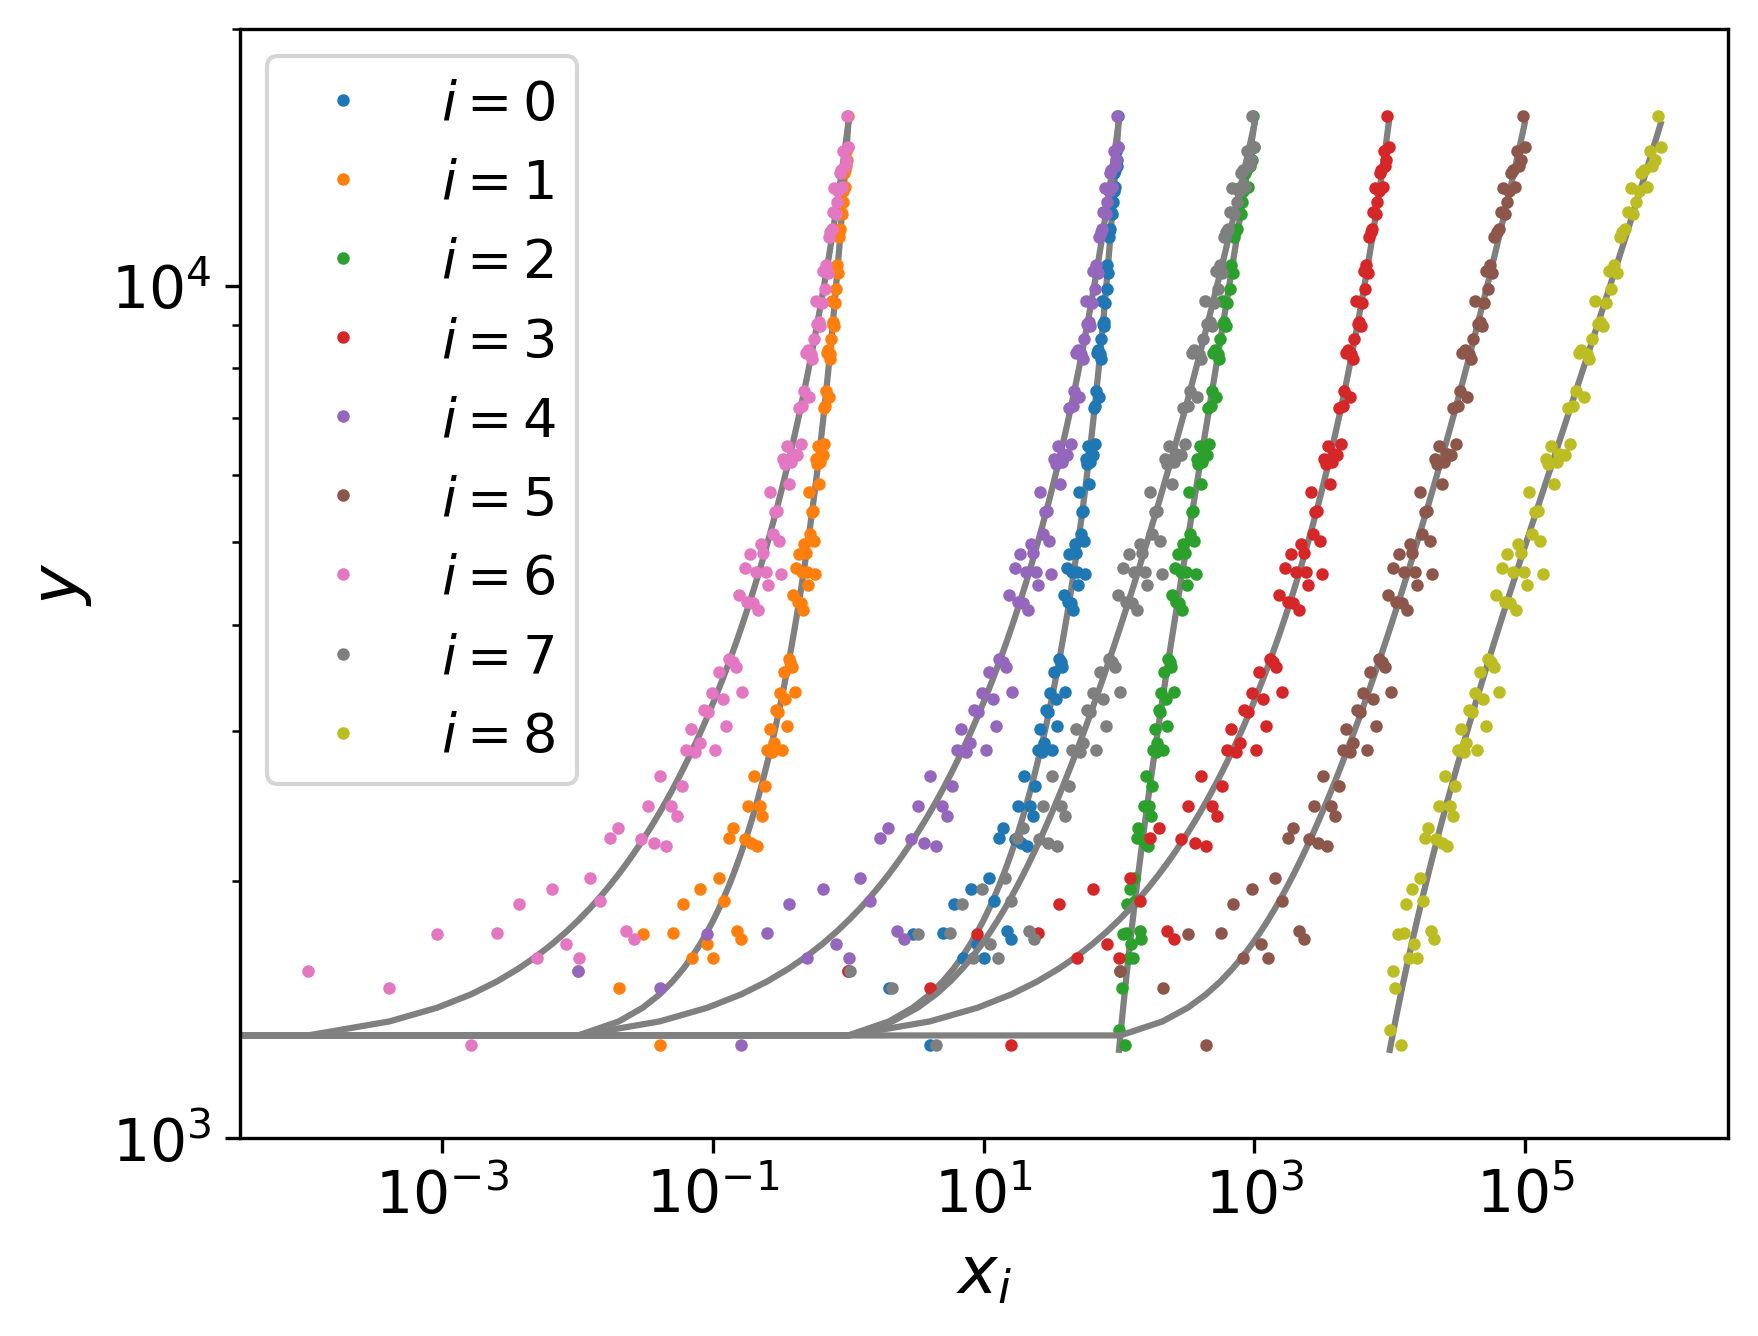

In [28]:
ypred = regm.predict(new_xb)
fig5 = plt.figure()
for i in range(9) :
    plt.plot(new_xb[:,i], ypred1, '-', c='gray')
    plt.plot(new_xb[:,i], ypb,'o', ms=2, label='$i=$'+str(i))
plt.legend(loc='best',fontsize=13)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$x_i$')
plt.ylabel('$y$')
plt.ylim(1e3,2e4)